In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import pandas as pd; pd.set_option("display.max_columns", None)
import sys;sys.path.append("..")
from config import Paths
from dataframes import *
from eals_data.utils import venn_diagram
from eals_radcliff.utils import dataframes as radcliff_dataframes
from eals_radcliff.utils import dataframes_paper as radcliff_dataframes_paper

GT_PATH = '../data/RAPA EALS Participant Data Set v1 04-13-2026.xlsx'

In [11]:
df_zx = load_zephyrx_data(
    at_least_efforts_fvc_usable=0,
    keep_usable_sessions_only=False,
    at_least_months_in_study=0,
    at_least_n_sessions=0,
    multiply_by_100=False,
)
print(f'N pALS: {df_zx.user_id.nunique()}, N sessions: {df_zx.session_id.nunique()}')

1 - ORIGINAL DIMENSIONS:                           subjects:     13, sessions:    126, spiro:    295, cols: 108
--- KEEP SESSIONS THAT MAY NOT MET USABILITY CRITERIA (eals_usability column)
--- WARNING computing 'total_timespan' for each user after usability criteria: False
--- TOTAL TIMESPAN: min 0, max 671, mean 341.71
--- NOT FILTERING SUBJECTS BY MINIMUM MONTHS IN STUDY
--- NOT FILTERING SUBJECTS BY MINIMUM NUMBER OF SESSIONS
N pALS: 13, N sessions: 126


In [12]:
df = pd.read_excel(GT_PATH)
df = df.rename(columns={'EALS ID': 'user_id', 'RAPA ID': 'rapa_id'})
rapa_to_eals = {row['rapa_id']:row['user_id'] for i, row in df[['user_id','rapa_id']].drop_duplicates().iterrows()}
rapa_to_eals

{'501-EAP-05-005': '623d5c97-db0b-41a5-aaac-9fd096ca3fa5',
 '501-EAP-03-012': 'b96c8a5b-8902-423a-8ced-18f6b01e9885',
 '501-EAP-03-011': 'f8823c7d-30bb-47f6-855c-e71b1962f1af',
 '501-EAP-10-001': 'e988b6b3-6cca-43f2-8a2e-50e2c53c6a3b',
 '501-EAP-01-012': '9c09639d-2956-4110-8f63-7aada0e25173',
 '501-EAP-03-009': '75f732c6-c4b2-46df-8757-868b847aa3b0',
 '501-EAP-05-003': '9485abe1-c1b5-4d27-8540-12b0f9807782',
 '501-EAP-03-008': '8adba8d9-edd8-434c-b794-b2077322fc13',
 '501-EAP-06-002': '1b0b349e-301f-46a4-a137-1fed70ca678d',
 '501-EAP-03-004': 'a1568d21-c1f4-447c-8a4d-3565003d4773',
 '501-EAP-03-006': 'c2cc4d94-b103-407a-86f4-fb707b385a82',
 '501-EAP-03-001': '7ed30a17-32ec-4945-8598-1f08051e2e8d',
 '501-EAP-01-008': 'ca0d5d71-4c18-45e7-8c04-81feb7695e24',
 '501-EAP-01-001': 'cee20458-8561-4496-932c-6855e6299641',
 '501-EAP-01-002': 'a07848cb-83b1-48ef-a314-ae5b5e5d448b'}

In [13]:
TARGET_COLS = ['Date', 'Visit Type', 'Source']

def parse_sheet(xl, sheet):
    raw = xl.parse(sheet, header=None)
    mask = raw.apply(lambda row: row.astype(str).str.strip().tolist(), axis=1).apply(
        lambda vals: all(c in vals for c in TARGET_COLS)
    )
    header_row = mask.idxmax()
    raw.columns = raw.iloc[header_row]
    return raw.iloc[header_row + 1:][TARGET_COLS].reset_index(drop=True)

xl = pd.ExcelFile(GT_PATH)
sheet_names = xl.sheet_names
sheets = {sheet_names[0]: xl.parse(sheet_names[0])}
sheets.update({sheet: parse_sheet(xl, sheet) for sheet in sheet_names[1:]})
sheets = {rapa_to_eals.get(k.split(',')[0].strip(), k):v for k,v in sheets.items()}
sheets.keys()

dict_keys(['EALS Data Set', 'cee20458-8561-4496-932c-6855e6299641', 'a07848cb-83b1-48ef-a314-ae5b5e5d448b', 'ca0d5d71-4c18-45e7-8c04-81feb7695e24', '7ed30a17-32ec-4945-8598-1f08051e2e8d', 'c2cc4d94-b103-407a-86f4-fb707b385a82', 'a1568d21-c1f4-447c-8a4d-3565003d4773', '1b0b349e-301f-46a4-a137-1fed70ca678d', '8adba8d9-edd8-434c-b794-b2077322fc13'])

In [14]:
df_with_svc = df_zx.query('pftType in ["svc"]')[['user_id','date','vcPercPred']].drop_duplicates(keep='last')
df_with_svc.user_id.nunique()

12

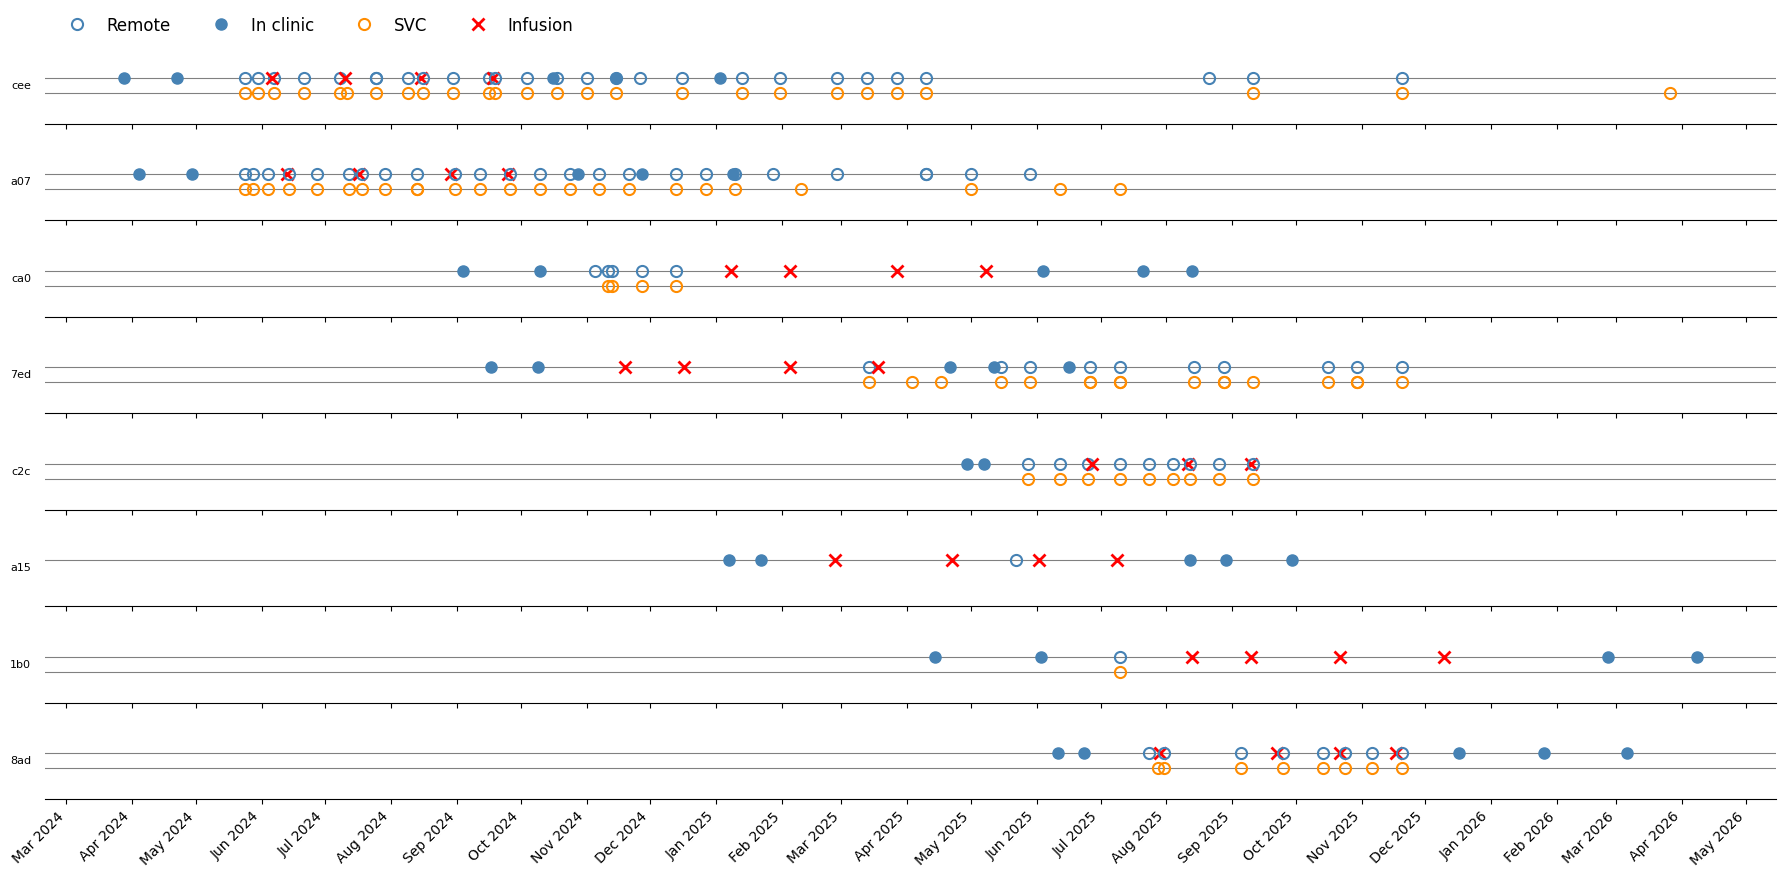

In [15]:
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

CYCLE_VISITS = {"C1D1", "C2D1", "C3D1", "C4D1"}
subject_names = list(sheets.keys())[1:]
n = len(subject_names)

fig, axes = plt.subplots(n, 1, figsize=(18, n * 1.1), sharex=True)
if n == 1:
    axes = [axes]

for ax, name in zip(axes, subject_names):
    df_s = sheets[name].copy()
    df_s["Date"] = pd.to_datetime(df_s["Date"], dayfirst=False, infer_datetime_format=True, errors="coerce")
    df_s = df_s.dropna(subset=["Date"])

    for _, row in df_s.iterrows():
        x = row["Date"]
        is_cycle = row["Visit Type"] in CYCLE_VISITS
        is_rapa  = str(row["Source"]).strip().upper() == "RAPA"

        if is_cycle:
            ax.plot(x, 0.6, marker="x", color="red", markersize=9, markeredgewidth=2, linestyle="none")
        elif is_rapa:
            ax.plot(x, 0.6, marker="o", color="steelblue", markersize=8, linestyle="none")
        else:  # EALS — remote
            ax.plot(x, 0.6, marker="o", color="steelblue", markersize=8,
                    markerfacecolor="none", markeredgewidth=1.5, linestyle="none")

    ax.axhline(0.6, color="gray", linewidth=0.8, zorder=0)

    # second line: df_with_svc sessions for this subject
    df_sub = df_with_svc[df_with_svc["user_id"] == name].copy()
    if len(df_sub):
        df_sub["date"] = pd.to_datetime(df_sub["date"], errors="coerce")
        df_sub = df_sub.dropna(subset=["date"])
        for x2 in df_sub["date"]:
            ax.plot(x2, 0.4, marker="o", color="darkorange", markersize=8,
                    markerfacecolor="none", markeredgewidth=1.5, linestyle="none")
        ax.axhline(0.4, color="gray", linewidth=0.8, zorder=0)

    ax.set_ylabel(name[:3], rotation=0, labelpad=10, ha="right", va="center", fontsize=8)
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.spines[["top", "right", "left"]].set_visible(False)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=45)

legend_handles = [
    Line2D([0], [0], marker="o", color="steelblue", markerfacecolor="none", markeredgewidth=1.5,
           markersize=8, linestyle="none", label="Remote"),
    Line2D([0], [0], marker="o", color="steelblue", markersize=8,
           linestyle="none", label="In clinic"),
    Line2D([0], [0], marker="o", color="darkorange", markerfacecolor="none", markeredgewidth=1.5,
           markersize=8, linestyle="none", label="SVC"),
    Line2D([0], [0], marker="x", color="red", markersize=9, markeredgewidth=2,
           linestyle="none", label="Infusion"),
]
axes[0].legend(handles=legend_handles, loc="upper left", fontsize=12, frameon=False,
               ncol=4, bbox_to_anchor=(0, 1.6))

fig.tight_layout()
plt.show()

In [96]:
name = subject_names[0]
print(name)
df_s = sheets[name].copy()
df_s["Date"] = pd.to_datetime(df_s["Date"], dayfirst=False, infer_datetime_format=True, errors="coerce")
print((~(df_s.sort_values('Date').index == df_s.index)).sum())
df_both = df_s.merge(df_with_svc.query('user_id==@name').drop(columns=['user_id']), how='outer', left_on='Date', right_on='date')
df_both

cee20458-8561-4496-932c-6855e6299641
2


,Date,Visit Type,Source,date,vcPercPred
0,2024-03-28,Screening,RAPA,NaT,NaN
1,2024-04-22,Apheresis (Day 0),RAPA,NaT,NaN
2,2024-05-24,Baseline,EALS,2024-05-24,0.60
3,2024-05-30,Baseline,EALS,2024-05-30,0.46
4,2024-06-07,Baseline,EALS,2024-06-07,0.46
5,2024-06-06,C1D1,RAPA,NaT,NaN
6,2024-06-21,Post-Infusion C1D1,EALS,2024-06-21,0.49
7,2024-07-08,Recurring,EALS,2024-07-08,0.40
8,2024-07-10,C2D1,RAPA,NaT,NaN
9,2024-07-25,Post-Infusion C2D1,EALS,2024-07-25,0.45


In [95]:
df_zx_min = df_zx[['user_id','date','vcPercPred','fvcPercPred_2019']].query('user_id==@name')
"2025-01-03" in df_zx_min.date.astype(str).values

False